## House Price Prediction

In [3]:
## 📦 Step 1: Generate Dataset

In [9]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Features
n = 500
area = np.random.randint(500, 4000, n)        # sq ft
bedrooms = np.random.randint(1, 6, n)
age = np.random.randint(0, 30, n)

# Target (price)
price = (
    area * 3000 +
    bedrooms * 50000 -
    age * 2000 +
    np.random.normal(0, 100000, n)   # noise
)

# Create DataFrame
df = pd.DataFrame({
    "area": area,
    "bedrooms": bedrooms,
    "age": age,
    "price": price
})

print(df.head())

   area  bedrooms  age         price
0  3674         4   23  1.127892e+07
1  1360         2    5  4.217260e+06
2  1794         3    1  5.555603e+06
3  1630         4   19  5.150269e+06
4  1595         5   27  5.147547e+06


In [10]:
# 📊 Step 2: Train Models

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import r2_score

# Split
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Models
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5)
rf = RandomForestRegressor(n_estimators=50)

# Voting Regressor
vr = VotingRegressor(
    estimators=[('lr', lr), ('dt', dt), ('rf', rf)],
    weights=[1, 1, 3]
)

# Train
for model in [lr, dt, rf, vr]:
    model.fit(X_train, y_train)

# Evaluate
for name, model in zip(["LR", "DT", "RF", "Voting"], [lr, dt, rf, vr]):
    y_pred = model.predict(X_test)
    print(f"{name}: {r2_score(y_test, y_pred):.3f}")

LR: 0.999
DT: 0.997
RF: 0.998
Voting: 0.998


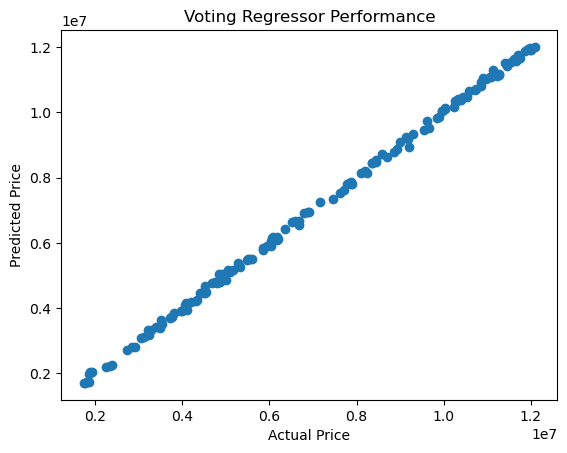

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, vr.predict(X_test))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Voting Regressor Performance")
plt.show()